# 05b: Cross-station transfer evaluation

Applies the locked Makiki detector rules to three external stations. Discharge BOCPD is the primary comparison; turbidity BOCPD is secondary.


## Setup


In [1]:
import json, pathlib, warnings
import numpy  as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy.special import gammaln

warnings.filterwarnings("ignore", category=FutureWarning)
RNG = np.random.default_rng(20240604)

NOTEBOOK_DIR  = pathlib.Path(".").resolve()
PROJECT_ROOT  = NOTEBOOK_DIR.parent
PROCESSED_DIR = PROJECT_ROOT / "Data"    / "Processed"
FIG_DIR       = PROJECT_ROOT / "Outputs" / "Figures"
TABLE_DIR     = PROJECT_ROOT / "Outputs" / "Tables"
CONFIG_DIR    = PROJECT_ROOT / "Outputs" / "Config"
for d in (PROCESSED_DIR, FIG_DIR, TABLE_DIR, CONFIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

HST = "Pacific/Honolulu"
SAVE_OUTPUTS = True

# External transfer stations.


EXTERNAL_STATIONS = {
    "16247100": "Manoa-Palolo Drainage Canal at Moiliili",
    "16265000": "Kawa Stream at Kaneohe",
    "16274100": "Kaneohe Stream below Kamehameha Hwy",
}
MAKIKI_ID = "16238000"

OUT_T = {
    "primary_results"   : TABLE_DIR / "makiki_05b_primary_transfer_results.csv",
    "turbidity_results"  : TABLE_DIR / "makiki_05b_turbidity_secondary_results.csv",
    "final_table"        : TABLE_DIR / "makiki_05b_cross_station_final.csv",
    "descriptive_pooled" : TABLE_DIR / "makiki_05b_descriptive_pooled.csv",
}
OUT_F = {
    "recall_burden_fig": FIG_DIR / "makiki_05b_cross_station_recall_burden.png",
}

def instrumented_path(site_id, variable):
    return PROCESSED_DIR / f"{site_id}_bocpd_instrumented_{variable}.csv.gz"

def alarms_path(site_id, method):
    return PROCESSED_DIR / f"{site_id}_alarms_{method}.csv"

def matches_path(site_id, method):
    return PROCESSED_DIR / f"{site_id}_matches_{method}.csv"

plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"white",
    "axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.25,"font.size":10,
    "font.family":"DejaVu Sans",
})

def save_csv(df, path, label="", gz=False):
    path = pathlib.Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False, compression="gzip" if gz else None)
    print(f"  Saved {label or path.name}  ({len(df):,} rows)")

def save_fig(path, fig=None, dpi=140):
    (fig or plt).savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    plt.show(); plt.close("all")
    print(f"  Saved: {pathlib.Path(path).name}")

def combined_legend(ax_primary, *other_axes, loc="upper left", fontsize=8.5):
    handles, labels = ax_primary.get_legend_handles_labels()
    for ax in other_axes:
        h, l = ax.get_legend_handles_labels()
        handles += h; labels += l
    ax_primary.legend(handles, labels, loc=loc, fontsize=fontsize)

def find_file(names, dir_, required=True):
    for n in names:
        p = pathlib.Path(dir_) / n
        if p.exists(): return p
    if required:
        raise FileNotFoundError(f"Missing file: {[str(pathlib.Path(dir_)/n) for n in names]}")
    return None

def wilson_ci(successes: int, n: int, z: float = 1.96):
    if n == 0: return (np.nan, np.nan, np.nan)
    phat = successes / n
    denom = 1 + z**2/n
    center = (phat + z**2/(2*n)) / denom
    half = (z/denom) * np.sqrt(phat*(1-phat)/n + z**2/(4*n**2))
    return (phat, max(0.0, center-half), min(1.0, center+half))

print("Setup complete.")


Setup complete.


## Section 0: Load locked settings and station data

Only models marked `validated` or `validated_with_degradation` are transferred.


In [2]:
LOCKED_PATH = find_file(["makiki_04g_locked_config.json"], dir_=CONFIG_DIR, required=False)
if LOCKED_PATH is not None:
    with open(LOCKED_PATH) as f:
        LOCKED = json.load(f)["models"]
else:
    locked_csv_path = find_file(["makiki_04g_locked_config.csv"], dir_=TABLE_DIR, required=True)
    locked_df = pd.read_csv(locked_csv_path)
    LOCKED = {row["model"]: row.to_dict() for _, row in locked_df.iterrows()}
    print(f"  Loaded from CSV fallback: {locked_csv_path.name}")

TRANSFERABLE_STATUSES = {"validated", "validated_with_degradation"}
MODELS_TO_RUN = {}
for model, cfg in LOCKED.items():
    status = cfg.get("status")
    eligible = status in TRANSFERABLE_STATUSES
    print(f"  {model}: status={status}  -> {'TRANSFERS' if eligible else 'excluded from cross-station work'}")
    if eligible:
        MODELS_TO_RUN[model] = cfg

assert "discharge_bocpd" in MODELS_TO_RUN, "discharge_bocpd not transferable"
DISCHARGE_CFG = MODELS_TO_RUN["discharge_bocpd"]
TURBIDITY_CFG = MODELS_TO_RUN.get("turbidity_bocpd")  
print(f"\nDischarge locked rule : score={DISCHARGE_CFG['score']}, quantile={DISCHARGE_CFG['quantile']}, "
      f"extraction={DISCHARGE_CFG.get('extraction_method')}, merge_gap={DISCHARGE_CFG.get('merge_gap_hours')}h, "
      f"persist_steps={DISCHARGE_CFG.get('persist_steps')}")
if TURBIDITY_CFG:
    print(f"Turbidity locked rule  : score={TURBIDITY_CFG['score']}, quantile={TURBIDITY_CFG['quantile']}, "
          f"refractory={TURBIDITY_CFG.get('refractory_hours')}h  [secondary: never determines headline result]")


  discharge_bocpd: status=validated  -> TRANSFERS
  static_discharge_p95: status=reference_baseline  -> excluded from cross-station work
  turbidity_bocpd: status=validated_with_degradation  -> TRANSFERS
  joint_bocpd: status=exploratory_do_not_transfer  -> excluded from cross-station work

Discharge locked rule : score=surprise, quantile=0.99, extraction=episode_clustering, merge_gap=3.0h, persist_steps=2
Turbidity locked rule  : score=surprise, quantile=0.975, refractory=6.0h  [secondary: never determines headline result]


In [3]:
ALL_STATION_IDS = [MAKIKI_ID] + list(EXTERNAL_STATIONS.keys())
STATION_DATA = {}
for site_id in ALL_STATION_IDS:
    iv = pd.read_csv(PROCESSED_DIR / f"{site_id}_iv_qc.csv", parse_dates=["datetime"])
    campaigns = pd.read_csv(PROCESSED_DIR / f"{site_id}_storm_campaigns.csv",
                              parse_dates=["first_sample_time","last_sample_time"])
    eligibility = pd.read_csv(PROCESSED_DIR / f"{site_id}_eligibility_audit.csv",
                                parse_dates=["first_sample_time","last_sample_time"])
    name = "Makiki Stream at King St. bridge" if site_id == MAKIKI_ID else EXTERNAL_STATIONS[site_id]
    STATION_DATA[site_id] = dict(iv=iv, campaigns=campaigns, eligibility=eligibility, name=name)
    n_dis_elig = int(eligibility["discharge_eligible"].sum())
    n_tur_elig = int(eligibility["turbidity_eligible"].sum())
    role = "(development site)" if site_id == MAKIKI_ID else "(external)"
    print(f"{site_id} {role} ({name}): {len(campaigns)} campaigns, discharge_eligible={n_dis_elig}, "
          f"turbidity_eligible={n_tur_elig}")


16238000 (development site) (Makiki Stream at King St. bridge): 76 campaigns, discharge_eligible=36, turbidity_eligible=27
16247100 (external) (Manoa-Palolo Drainage Canal at Moiliili): 26 campaigns, discharge_eligible=20, turbidity_eligible=16
16265000 (external) (Kawa Stream at Kaneohe): 56 campaigns, discharge_eligible=36, turbidity_eligible=34
16274100 (external) (Kaneohe Stream below Kamehameha Hwy): 53 campaigns, discharge_eligible=45, turbidity_eligible=36


## Section 1: Run BOCPD

Saves surprise, changepoint probability, MAP run length, MAP drop, and short-run mass for later figures.


In [4]:
K_MAX = 400
PRUNE_THR = 1e-12
SHORT_RUN_KS = [1, 3, 6]
HEADLINE_HAZARD_H = 24

class UnivariateNIG:
    def __init__(self, mu0=0.0, kappa0=1.0, alpha0=2.0, beta0=1.0):
        self.mu0, self.kappa0, self.alpha0, self.beta0 = mu0, kappa0, alpha0, beta0
    def init_params(self):
        return (np.array([self.mu0]), np.array([self.kappa0]),
                np.array([self.alpha0]), np.array([self.beta0]))
    def log_pred(self, params, x):
        mu, kappa, alpha, beta = params
        df = 2*alpha; scale2 = beta*(kappa+1)/(kappa*alpha); z = (x - mu)
        return (gammaln((df+1)/2) - gammaln(df/2) - 0.5*np.log(df*np.pi*scale2)
                - (df+1)/2 * np.log1p(z**2/(df*scale2)))
    def update(self, params, x):
        mu, kappa, alpha, beta = params
        kappa1 = kappa + 1; mu1 = (kappa*mu + x)/kappa1
        alpha1 = alpha + 0.5; beta1 = beta + 0.5*kappa*(x-mu)**2/kappa1
        return (mu1, kappa1, alpha1, beta1)

def run_bocpd_instrumented(x, hazard_lambda, model, k_max=K_MAX):
    T = len(x); H = 1.0/hazard_lambda
    params = model.init_params(); R = np.array([1.0])
    cp_prob = np.zeros(T); map_rl = np.zeros(T, dtype=int)
    short_mass = {k: np.zeros(T) for k in SHORT_RUN_KS}
    surprise = np.zeros(T); map_drop = np.zeros(T); prev_map_rl = 0
    for t in range(T):
        xt = x[t]
        p0 = model.init_params()
        lp0 = float(model.log_pred(p0, xt)[0])
        lpc = model.log_pred(params, xt)
        lmax = max(lp0, float(lpc.max()) if len(lpc) else -np.inf)
        pf = np.exp(lp0 - lmax); pc = np.exp(lpc - lmax)
        cp_mass = pf*H; growth = R*pc*(1-H)
        R_new = np.concatenate([[cp_mass], growth])
        s_unnorm = float(R_new.sum())
        surprise[t] = -(np.log(max(s_unnorm, 1e-300)) + lmax)
        if len(R_new) > k_max:
            R_new[0] += R_new[k_max:].sum(); R_new = R_new[:k_max]
        R_new[R_new < PRUNE_THR] = 0.0
        s = R_new.sum()
        if s > 0: R_new /= s
        cp_prob[t] = float(R_new[0])
        cur_map_rl = int(np.argmax(R_new)); map_rl[t] = cur_map_rl
        map_drop[t] = max(0, prev_map_rl + 1 - cur_map_rl); prev_map_rl = cur_map_rl
        for k in SHORT_RUN_KS: short_mass[k][t] = float(R_new[:k+1].sum())
        K_new = len(R_new)
        mu_n  = np.concatenate([p0[0], params[0]])[:K_new]
        ka_n  = np.concatenate([p0[1], params[1]])[:K_new]
        al_n  = np.concatenate([p0[2], params[2]])[:K_new]
        be_n  = np.concatenate([p0[3], params[3]])[:K_new]
        params = model.update((mu_n,ka_n,al_n,be_n), xt)
        R = R_new
    out = dict(cp_prob=cp_prob, map_runlength=map_rl, map_drop=map_drop, surprise=surprise)
    for k in SHORT_RUN_KS: out[f"short_run_mass_{k}"] = short_mass[k]
    return out

def mask_to_segments(mask: pd.Series, min_len_steps: int = 1):
    arr = mask.values.astype(int)
    if arr.sum() == 0: return []
    diff = np.diff(np.concatenate([[0], arr, [0]]))
    starts = np.where(diff == 1)[0]; ends = np.where(diff == -1)[0] - 1
    return [(mask.index[s], mask.index[e]) for s, e in zip(starts, ends) if (e - s + 1) >= min_len_steps]

def run_segment_set_instrumented(segments, series, hazard_h=HEADLINE_HAZARD_H, cadence_sec=300):
    steps_per_h = int(round(3600/cadence_sec))
    hazard_steps = hazard_h * steps_per_h
    rows = []
    for sid, (t0, t1) in enumerate(segments):
        X = series.loc[t0:t1].values
        valid = ~np.isnan(X)
        idx = series.loc[t0:t1].index
        if valid.sum() < 10: continue
        model = UnivariateNIG(0.0, 1.0, 2.0, 1.0)
        out = run_bocpd_instrumented(X[valid], hazard_steps, model)
        d = {"datetime": idx[valid], "segment_id": sid}; d.update(out)
        rows.append(pd.DataFrame(d))
    if not rows: return pd.DataFrame(columns=["datetime","segment_id","cp_prob","map_runlength",
                                                 "map_drop","surprise"]+[f"short_run_mass_{k}" for k in SHORT_RUN_KS])
    return pd.concat(rows, ignore_index=True)

def load_or_compute_instrumented(site_id, variable, segments, series, cadence_sec):
    cache_candidates = []
    if site_id == MAKIKI_ID:
        cache_candidates = [f"makiki_04b_bocpd_instrumented_{variable}.csv.gz"]
    cache_path = find_file(cache_candidates, dir_=PROCESSED_DIR, required=False) if cache_candidates else None
    if cache_path is not None:
        df = pd.read_csv(cache_path, parse_dates=["datetime"])
        print(f"  {site_id}/{variable}: using CACHED instrumented scores from {cache_path.name} ({len(df):,} rows)")
        return df
    print(f"  {site_id}/{variable}: NOT CACHED: computing fresh ({len(segments)} segments) ...")
    df = run_segment_set_instrumented(segments, series, cadence_sec=cadence_sec)
    print(f"    -> {len(df):,} timesteps")
    return df

STATION_SURPRISE = {}
STATION_GRIDS = {}
for site_id, sd in STATION_DATA.items():
    iv = sd["iv"].set_index("datetime")
    diffs_sec = iv.index.to_series().diff().dt.total_seconds().dropna()
    cadence_sec = float(diffs_sec.median())
    cadence_min = int(round(cadence_sec/60))
    grid_idx = pd.date_range(iv.index.min(), iv.index.max(), freq=f"{cadence_min}min", tz="UTC")
    iv_grid = iv.reindex(grid_idx)
    dis_grid, tur_grid = iv_grid["discharge_cfs"], iv_grid["turbidity_fnu"]
    z_dis, z_tur = iv_grid["z_log_discharge"], iv_grid["z_log_turbidity"]

    min_seg_steps = int(pd.Timedelta(hours=6) / pd.Timedelta(seconds=cadence_sec))
    dis_segments = mask_to_segments(dis_grid.notna(), min_seg_steps)
    tur_segments = mask_to_segments(tur_grid.notna(), min_seg_steps)

    instr_dis = load_or_compute_instrumented(site_id, "discharge", dis_segments, z_dis, cadence_sec)
    instr_tur = load_or_compute_instrumented(site_id, "turbidity", tur_segments, z_tur, cadence_sec)

    STATION_SURPRISE[site_id] = dict(discharge=instr_dis, turbidity=instr_tur)
    STATION_GRIDS[site_id] = dict(dis_grid=dis_grid, cadence_sec=cadence_sec)

    if SAVE_OUTPUTS:
        if len(instr_dis): save_csv(instr_dis, instrumented_path(site_id,"discharge"), f"{site_id} instrumented discharge", gz=True)
        if len(instr_tur): save_csv(instr_tur, instrumented_path(site_id,"turbidity"), f"{site_id} instrumented turbidity", gz=True)


  16238000/discharge: using CACHED instrumented scores from makiki_04b_bocpd_instrumented_discharge.csv.gz (388,548 rows)
  16238000/turbidity: using CACHED instrumented scores from makiki_04b_bocpd_instrumented_turbidity.csv.gz (258,470 rows)
  Saved 16238000 instrumented discharge  (388,548 rows)
  Saved 16238000 instrumented turbidity  (258,470 rows)
  16247100/discharge: NOT CACHED: computing fresh (256 segments) ...
    -> 400,683 timesteps
  16247100/turbidity: NOT CACHED: computing fresh (1419 segments) ...
    -> 289,532 timesteps
  Saved 16247100 instrumented discharge  (400,683 rows)
  Saved 16247100 instrumented turbidity  (289,532 rows)
  16265000/discharge: NOT CACHED: computing fresh (80 segments) ...
    -> 424,984 timesteps
  16265000/turbidity: NOT CACHED: computing fresh (1470 segments) ...
    -> 324,874 timesteps
  Saved 16265000 instrumented discharge  (424,984 rows)
  Saved 16265000 instrumented turbidity  (324,874 rows)
  16274100/discharge: NOT CACHED: computing

## Section 2: Extract and match alarms


In [5]:
def static_alarms(above_mask, persist_steps, merge_gap, label="static"):
    arr = above_mask.fillna(False).values.astype(int)
    idx = above_mask.index
    diff = np.diff(np.concatenate([[0], arr, [0]]))
    starts = np.where(diff==1)[0]; ends = np.where(diff==-1)[0]-1
    episodes = [(idx[s], idx[e]) for s,e in zip(starts,ends) if (e-s+1) >= persist_steps]
    if not episodes: return pd.DataFrame(columns=["alarm_time","alarm_end","method"])
    merged = [episodes[0]]
    for s,e in episodes[1:]:
        if s - merged[-1][1] <= merge_gap: merged[-1] = (merged[-1][0], e)
        else: merged.append((s,e))
    return pd.DataFrame({"alarm_time":[m[0] for m in merged], "alarm_end":[m[1] for m in merged], "method":label})

def extract_alarms_debounce(score_df, score_col, threshold, refractory_h):
    above = score_df[score_col] >= threshold
    if not above.any(): return pd.DataFrame(columns=["alarm_time"])
    dts = pd.DatetimeIndex(score_df["datetime"])
    alarm_times = dts[above.values]
    refractory = pd.Timedelta(hours=refractory_h)
    merged = [alarm_times[0]]
    for t in alarm_times[1:]:
        if t - merged[-1] > refractory: merged.append(t)
    return pd.DataFrame({"alarm_time": merged})

def extract_alarms_episode(score_df, score_col, threshold, merge_gap_h, persist_steps=2):
    above_mask = pd.Series(score_df[score_col].values >= threshold,
                             index=pd.DatetimeIndex(score_df["datetime"]))
    above_mask = above_mask[~above_mask.index.duplicated(keep="last")].sort_index()
    episodes = static_alarms(above_mask, persist_steps=persist_steps,
                                merge_gap=pd.Timedelta(hours=merge_gap_h), label="episode")
    return episodes[["alarm_time"]] if "alarm_time" in episodes.columns else pd.DataFrame(columns=["alarm_time"])

def extract_alarms(score_df, score_col, threshold, cfg):
    if cfg.get("extraction_method") == "episode_clustering":
        return extract_alarms_episode(score_df, score_col, threshold,
                                        cfg["merge_gap_hours"], persist_steps=int(cfg.get("persist_steps", 2)))
    elif pd.notna(cfg.get("refractory_hours")):
        return extract_alarms_debounce(score_df, score_col, threshold, cfg["refractory_hours"])
    else:
        raise ValueError(f"Missing extraction settings: {cfg}")

def match_with_window(alarms, before_h, after_h, campaigns):
    win_before = pd.Timedelta(hours=before_h); win_after = pd.Timedelta(hours=after_h)
    rows = []; matched_idx = set()
    for _, c in campaigns.iterrows():
        lo, hi = c["first_sample_time"]-win_before, c["last_sample_time"]+win_after
        in_win = alarms[(alarms["alarm_time"]>=lo)&(alarms["alarm_time"]<=hi)] if len(alarms) else pd.DataFrame()
        detected = len(in_win) > 0
        lead_lag = np.nan
        if detected:
            lead_lag = (in_win["alarm_time"].min() - c["first_sample_time"]).total_seconds()/60
            matched_idx.update(in_win.index.tolist())
        rows.append(dict(campaign_id=c["campaign_id"], detected=detected,
                           n_alarms_in_window=len(in_win), lead_lag_minutes=lead_lag))
    return pd.DataFrame(rows), matched_idx

def summarize_burden(alarms, match_table, matched_idx, period_months):
    n_alarms = len(alarms); n_matched = len(matched_idx); n_unmatched = n_alarms - n_matched
    matched_frac = (n_matched/n_alarms) if n_alarms else np.nan
    unmatched_per_month = (n_unmatched/period_months) if period_months > 0 else np.nan
    detected_camps = match_table[match_table["detected"]]
    dup_per_campaign = float(detected_camps["n_alarms_in_window"].mean()) if len(detected_camps) else np.nan
    lead_lag_vals = match_table.loc[match_table["detected"], "lead_lag_minutes"]
    return dict(n_alarms=n_alarms, n_matched_alarms=n_matched, n_unmatched_alarms=n_unmatched,
                 matched_alarm_fraction=round(matched_frac,4) if pd.notna(matched_frac) else np.nan,
                 unmatched_alarms_per_month=round(unmatched_per_month,3) if pd.notna(unmatched_per_month) else np.nan,
                 duplicate_alarms_per_campaign=round(dup_per_campaign,3) if pd.notna(dup_per_campaign) else np.nan,
                 median_lead_lag_minutes=round(float(lead_lag_vals.median()),1) if len(lead_lag_vals) else np.nan)

def evaluate_method(alarms, campaigns, period_months, before_h=6, after_h=6):
    m, matched_idx = match_with_window(alarms, before_h, after_h, campaigns)
    n_detected = int(m["detected"].sum()) if len(m) else 0
    n_total = len(campaigns)
    recall, ci_lo, ci_hi = wilson_ci(n_detected, n_total)
    burden = summarize_burden(alarms, m, matched_idx, period_months)
    return dict(n_eligible_campaigns=n_total, n_detected=n_detected,
                 recall=round(recall,4), ci_lo=round(ci_lo,4), ci_hi=round(ci_hi,4), **burden)


## Section 3: Compare discharge BOCPD with static p95

Uses the locked BOCPD quantile and the same static p95 rule at each station. Campaign matching uses a six-hour window on both sides.


In [6]:
PRIMARY_RESULTS = []
for site_id, sd in STATION_DATA.items():
    is_makiki = (site_id == MAKIKI_ID)
    elig = sd["eligibility"]
    campaigns = sd["campaigns"]
    dis_elig_camps = campaigns[campaigns["campaign_id"].isin(
        elig.loc[elig["discharge_eligible"], "campaign_id"])]

    dis_grid = STATION_GRIDS[site_id]["dis_grid"]
    period_months = (dis_grid.index.max() - dis_grid.index.min()).days / 30.44

    # Recompute the BOCPD threshold from each station's surprise distribution.
    instr_dis = STATION_SURPRISE[site_id]["discharge"]
    threshold_dis = float(instr_dis["surprise"].quantile(DISCHARGE_CFG["quantile"]))
    alarms_dis = extract_alarms(instr_dis, "surprise", threshold_dis, DISCHARGE_CFG)
    m_dis, matched_idx_dis = match_with_window(alarms_dis, 6, 6, dis_elig_camps)
    burden_dis = summarize_burden(alarms_dis, m_dis, matched_idx_dis, period_months)
    n_detected_dis = int(m_dis["detected"].sum()) if len(m_dis) else 0
    recall_dis, ci_lo_dis, ci_hi_dis = wilson_ci(n_detected_dis, len(dis_elig_camps))
    result_dis = dict(method="discharge_bocpd", site_id=site_id, threshold_value=round(threshold_dis,5),
                        n_eligible_campaigns=len(dis_elig_camps), n_detected=n_detected_dis,
                        recall=round(recall_dis,4), ci_lo=round(ci_lo_dis,4), ci_hi=round(ci_hi_dis,4), **burden_dis)

    # Recompute p95 from each station's discharge record.
    q95_station = float(np.nanpercentile(dis_grid.dropna(), 95))
    alarms_static = static_alarms(dis_grid > q95_station, persist_steps=2, merge_gap=pd.Timedelta(hours=1),
                                     label="static_discharge_p95")
    alarms_static = alarms_static[["alarm_time"]] if "alarm_time" in alarms_static.columns else pd.DataFrame(columns=["alarm_time"])
    m_static, matched_idx_static = match_with_window(alarms_static, 6, 6, dis_elig_camps)
    burden_static = summarize_burden(alarms_static, m_static, matched_idx_static, period_months)
    n_detected_static = int(m_static["detected"].sum()) if len(m_static) else 0
    recall_static, ci_lo_static, ci_hi_static = wilson_ci(n_detected_static, len(dis_elig_camps))
    result_static = dict(method="static_discharge_p95", site_id=site_id, threshold_value=round(q95_station,3),
                           n_eligible_campaigns=len(dis_elig_camps), n_detected=n_detected_static,
                           recall=round(recall_static,4), ci_lo=round(ci_lo_static,4), ci_hi=round(ci_hi_static,4), **burden_static)

    if SAVE_OUTPUTS:
        save_csv(alarms_dis, alarms_path(site_id,"discharge_bocpd"), f"{site_id} discharge_bocpd alarms")
        save_csv(m_dis, matches_path(site_id,"discharge_bocpd"), f"{site_id} discharge_bocpd matches")
        save_csv(alarms_static, alarms_path(site_id,"static_discharge_p95"), f"{site_id} static_p95 alarms")
        save_csv(m_static, matches_path(site_id,"static_discharge_p95"), f"{site_id} static_p95 matches")

    tag = " [Makiki: supplementary full-record artifacts, NOT the official held-out numbers]" if is_makiki else ""
    print(f"{site_id}: discharge_bocpd recall={result_dis['recall']:.3f} [{result_dis['ci_lo']:.3f},{result_dis['ci_hi']:.3f}], "
          f"static_p95 recall={result_static['recall']:.3f} [{result_static['ci_lo']:.3f},{result_static['ci_hi']:.3f}]{tag}")

    if not is_makiki:
        PRIMARY_RESULTS.append(result_dis)
        PRIMARY_RESULTS.append(result_static)

PRIMARY_RESULTS_DF = pd.DataFrame(PRIMARY_RESULTS)
print("\nPrimary transfer results, external stations only (official):")
print(PRIMARY_RESULTS_DF.to_string(index=False))

if SAVE_OUTPUTS:
    save_csv(PRIMARY_RESULTS_DF, OUT_T["primary_results"])


  Saved 16238000 discharge_bocpd alarms  (436 rows)
  Saved 16238000 discharge_bocpd matches  (36 rows)
  Saved 16238000 static_p95 alarms  (417 rows)
  Saved 16238000 static_p95 matches  (36 rows)
16238000: discharge_bocpd recall=0.944 [0.819,0.985], static_p95 recall=0.806 [0.650,0.902] [Makiki: supplementary full-record artifacts, NOT the official held-out numbers]
  Saved 16247100 discharge_bocpd alarms  (729 rows)
  Saved 16247100 discharge_bocpd matches  (20 rows)
  Saved 16247100 static_p95 alarms  (312 rows)
  Saved 16247100 static_p95 matches  (20 rows)
16247100: discharge_bocpd recall=0.950 [0.764,0.991], static_p95 recall=0.800 [0.584,0.919]
  Saved 16265000 discharge_bocpd alarms  (605 rows)
  Saved 16265000 discharge_bocpd matches  (36 rows)
  Saved 16265000 static_p95 alarms  (565 rows)
  Saved 16265000 static_p95 matches  (36 rows)
16265000: discharge_bocpd recall=1.000 [0.904,1.000], static_p95 recall=0.917 [0.782,0.971]
  Saved 16274100 discharge_bocpd alarms  (834 row

## Section 4: Run turbidity BOCPD

Only runs at stations with at least one turbidity-eligible campaign. This is secondary and does not change the primary comparison.


In [7]:
TURBIDITY_RESULTS = []
if TURBIDITY_CFG is None:
    print("Turbidity BOCPD is not in a transferable status: skipping secondary evaluation entirely.")
else:
    for site_id, sd in STATION_DATA.items():
        is_makiki = (site_id == MAKIKI_ID)
        elig = sd["eligibility"]
        campaigns = sd["campaigns"]
        n_tur_elig = int(elig["turbidity_eligible"].sum())
        if n_tur_elig == 0:
            print(f"{site_id}: 0 turbidity-eligible campaigns: gate not met, skipping.")
            continue

        tur_elig_camps = campaigns[campaigns["campaign_id"].isin(
            elig.loc[elig["turbidity_eligible"], "campaign_id"])]
        instr_tur = STATION_SURPRISE[site_id]["turbidity"]
        if len(instr_tur) == 0:
            print(f"{site_id}: no turbidity BOCPD scores available: skipping.")
            continue

        period_months = (instr_tur["datetime"].max() - instr_tur["datetime"].min()).days / 30.44
        threshold_tur = float(instr_tur["surprise"].quantile(TURBIDITY_CFG["quantile"]))
        alarms_tur = extract_alarms(instr_tur, "surprise", threshold_tur, TURBIDITY_CFG)
        m_tur, matched_idx_tur = match_with_window(alarms_tur, 6, 6, tur_elig_camps)
        burden_tur = summarize_burden(alarms_tur, m_tur, matched_idx_tur, period_months)
        n_detected_tur = int(m_tur["detected"].sum()) if len(m_tur) else 0
        recall_tur, ci_lo_tur, ci_hi_tur = wilson_ci(n_detected_tur, len(tur_elig_camps))
        result_tur = dict(method="turbidity_bocpd", site_id=site_id, threshold_value=round(threshold_tur,5),
                            n_eligible_campaigns=len(tur_elig_camps), n_detected=n_detected_tur,
                            recall=round(recall_tur,4), ci_lo=round(ci_lo_tur,4), ci_hi=round(ci_hi_tur,4), **burden_tur)

        if SAVE_OUTPUTS:
            save_csv(alarms_tur, alarms_path(site_id,"turbidity_bocpd"), f"{site_id} turbidity_bocpd alarms")
            save_csv(m_tur, matches_path(site_id,"turbidity_bocpd"), f"{site_id} turbidity_bocpd matches")

        tag = " [Makiki: supplementary, NOT the official held-out number]" if is_makiki else "  [SECONDARY: informational only]"
        print(f"{site_id}: turbidity_bocpd (n={n_tur_elig}) recall={result_tur['recall']:.3f} "
              f"[{result_tur['ci_lo']:.3f},{result_tur['ci_hi']:.3f}]{tag}")

        if not is_makiki:
            TURBIDITY_RESULTS.append(result_tur)

TURBIDITY_RESULTS_DF = pd.DataFrame(TURBIDITY_RESULTS)
if len(TURBIDITY_RESULTS_DF):
    print("\nSecondary turbidity results, external stations only (official):")
    print(TURBIDITY_RESULTS_DF.to_string(index=False))
    if SAVE_OUTPUTS:
        save_csv(TURBIDITY_RESULTS_DF, OUT_T["turbidity_results"])


  Saved 16238000 turbidity_bocpd alarms  (2,266 rows)
  Saved 16238000 turbidity_bocpd matches  (27 rows)
16238000: turbidity_bocpd (n=27) recall=1.000 [0.875,1.000] [Makiki: supplementary, NOT the official held-out number]
  Saved 16247100 turbidity_bocpd alarms  (2,413 rows)
  Saved 16247100 turbidity_bocpd matches  (16 rows)
16247100: turbidity_bocpd (n=16) recall=1.000 [0.806,1.000]  [SECONDARY: informational only]
  Saved 16265000 turbidity_bocpd alarms  (2,835 rows)
  Saved 16265000 turbidity_bocpd matches  (34 rows)
16265000: turbidity_bocpd (n=34) recall=0.971 [0.851,0.995]  [SECONDARY: informational only]
  Saved 16274100 turbidity_bocpd alarms  (3,731 rows)
  Saved 16274100 turbidity_bocpd matches  (36 rows)
16274100: turbidity_bocpd (n=36) recall=0.944 [0.819,0.985]  [SECONDARY: informational only]

Secondary turbidity results, external stations only (official):
         method  site_id  threshold_value  n_eligible_campaigns  n_detected  recall  ci_lo  ci_hi  n_alarms  n_mat

## Section 5: Build the cross-station table

Makiki values come from the locked configuration. External pooling is descriptive.


In [8]:
RESULT_COLS = ["recall","ci_lo","ci_hi","unmatched_alarms_per_month","matched_alarm_fraction",
                "duplicate_alarms_per_campaign","median_lead_lag_minutes","n_eligible_campaigns"]

def makiki_reference_row(model_key, method_label):
    cfg = LOCKED[model_key]
    return dict(method=method_label, site_id=MAKIKI_ID, role="development_site_reference",
                 recall=cfg.get("validated_recall"), ci_lo=cfg.get("ci_lo"), ci_hi=cfg.get("ci_hi"),
                 unmatched_alarms_per_month=cfg.get("test_period_unmatched_alarms_per_month"),
                 matched_alarm_fraction=cfg.get("test_period_matched_alarm_fraction"),
                 duplicate_alarms_per_campaign=cfg.get("test_period_duplicate_alarms_per_campaign"),
                 median_lead_lag_minutes=cfg.get("test_period_median_lead_lag_minutes"),
                 n_eligible_campaigns=cfg.get("n_eligible_campaigns"))

final_rows = []
for _, r in PRIMARY_RESULTS_DF.iterrows():
    d = r.to_dict(); d["role"] = "external_transfer_test"
    final_rows.append(d)
if len(TURBIDITY_RESULTS_DF):
    for _, r in TURBIDITY_RESULTS_DF.iterrows():
        d = r.to_dict(); d["role"] = "external_transfer_test_SECONDARY"
        final_rows.append(d)

final_rows.append(makiki_reference_row("discharge_bocpd", "discharge_bocpd"))
final_rows.append(makiki_reference_row("static_discharge_p95", "static_discharge_p95"))
if "turbidity_bocpd" in LOCKED:
    mak_tur = makiki_reference_row("turbidity_bocpd", "turbidity_bocpd")
    mak_tur["role"] = "development_site_reference_SECONDARY"
    final_rows.append(mak_tur)

FINAL_TABLE = pd.DataFrame(final_rows)
print("Final cross-station table:")
print(FINAL_TABLE[["method","site_id","role"]+RESULT_COLS].to_string(index=False))

# External pooling is descriptive.

pooled_rows = []
for method in ["discharge_bocpd", "static_discharge_p95"]:
    sub = PRIMARY_RESULTS_DF[PRIMARY_RESULTS_DF["method"]==method]
    total_eligible = int(sub["n_eligible_campaigns"].sum())
    total_detected = int(sub["n_detected"].sum())
    total_unmatched_per_month_avg = float(sub["unmatched_alarms_per_month"].mean())  
    pooled_rows.append(dict(method=method, total_detected=total_detected, total_eligible=total_eligible,
                              pooled_recall_descriptive=round(total_detected/total_eligible,4) if total_eligible else np.nan,
                              mean_unmatched_alarms_per_month=round(total_unmatched_per_month_avg,3),
                              note="DESCRIPTIVE ONLY: not an independent statistical test; 3 external stations with "
                                   "different eligible-campaign counts pooled by simple sum/mean."))
DESCRIPTIVE_POOLED = pd.DataFrame(pooled_rows)
print("\nDescriptive pooled summary (external stations only, NOT inferential):")
print(DESCRIPTIVE_POOLED.to_string(index=False))

if SAVE_OUTPUTS:
    save_csv(FINAL_TABLE, OUT_T["final_table"])
    save_csv(DESCRIPTIVE_POOLED, OUT_T["descriptive_pooled"])


Final cross-station table:
              method  site_id                                 role  recall  ci_lo  ci_hi  unmatched_alarms_per_month  matched_alarm_fraction  duplicate_alarms_per_campaign  median_lead_lag_minutes  n_eligible_campaigns
     discharge_bocpd 16247100               external_transfer_test  0.9500 0.7639 0.9911                       9.379                  0.0453                          1.737                    -75.0                    20
static_discharge_p95 16247100               external_transfer_test  0.8000 0.5840 0.9193                       3.962                  0.0577                          1.125                    -75.0                    20
     discharge_bocpd 16265000               external_transfer_test  1.0000 0.9036 1.0000                       7.425                  0.0893                          1.500                    -60.0                    36
static_discharge_p95 16265000               external_transfer_test  0.9167 0.7817 0.9713         

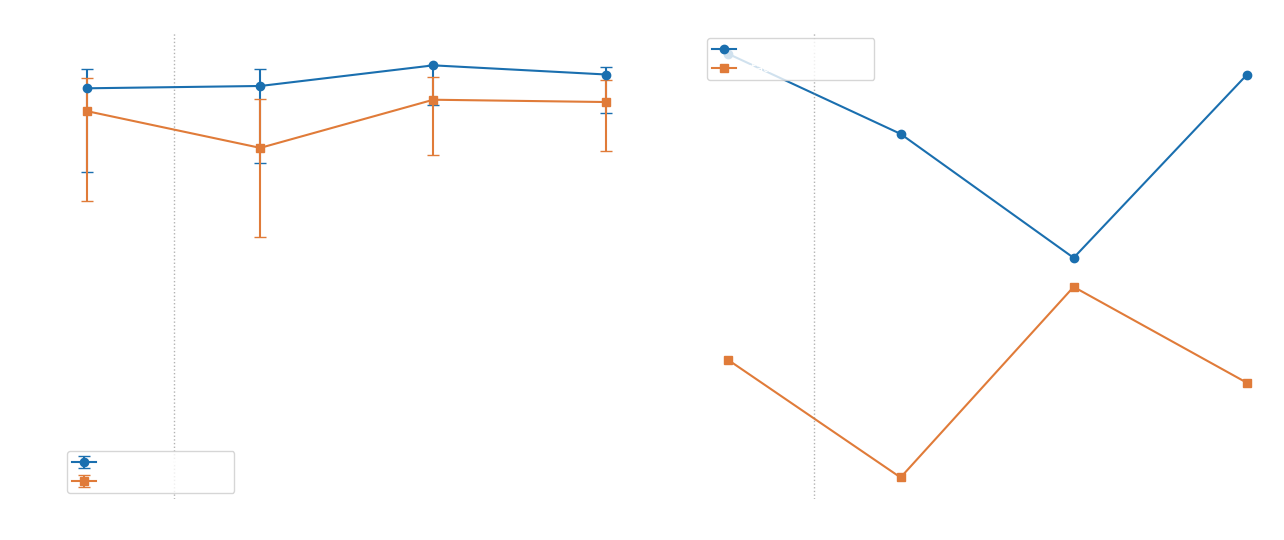

  Saved: makiki_05b_cross_station_recall_burden.png


In [9]:
primary_plot = FINAL_TABLE[FINAL_TABLE["method"].isin(["discharge_bocpd","static_discharge_p95"])].copy()
site_order = [MAKIKI_ID] + list(EXTERNAL_STATIONS.keys())
primary_plot["site_order"] = primary_plot["site_id"].apply(lambda s: site_order.index(s))
primary_plot = primary_plot.sort_values(["method","site_order"])

fig, axes = plt.subplots(1, 2, figsize=(13,5.5))
colors = {"discharge_bocpd":"#1a6faf", "static_discharge_p95":"#e07b39"}
markers = {"discharge_bocpd":"o", "static_discharge_p95":"s"}

ax = axes[0]
for method in ["discharge_bocpd","static_discharge_p95"]:
    sub = primary_plot[primary_plot["method"]==method]
    ax.errorbar(sub["site_order"], sub["recall"],
                 yerr=[sub["recall"]-sub["ci_lo"], sub["ci_hi"]-sub["recall"]],
                 fmt=markers[method]+"-", color=colors[method], capsize=4, label=method)
ax.axvline(0.5, color="grey", ls=":", lw=1, alpha=0.6)
ax.set_xticks(range(len(site_order))); ax.set_xticklabels(["Makiki\n(reference)"]+list(EXTERNAL_STATIONS.keys()), fontsize=8)
ax.set_ylabel("Recall (with 95% CI)"); ax.set_ylim(-0.05,1.08)
combined_legend(ax, loc="lower left", fontsize=8.5)
ax.set_title("Recall")

ax2 = axes[1]
for method in ["discharge_bocpd","static_discharge_p95"]:
    sub = primary_plot[primary_plot["method"]==method]
    ax2.plot(sub["site_order"], sub["unmatched_alarms_per_month"], markers[method]+"-", color=colors[method], label=method)
ax2.axvline(0.5, color="grey", ls=":", lw=1, alpha=0.6)
ax2.set_xticks(range(len(site_order))); ax2.set_xticklabels(["Makiki\n(reference)"]+list(EXTERNAL_STATIONS.keys()), fontsize=8)
ax2.set_ylabel("Unmatched alarms / month")
combined_legend(ax2, loc="upper left", fontsize=8.5)
ax2.set_title("Burden")
plt.tight_layout()
save_fig(OUT_F["recall_burden_fig"], fig)


## Summary


In [10]:
print("="*78)
print("NOTEBOOK 05b: CROSS-STATION TRANSFER EVALUATION SUMMARY")
print("="*78)
print("""
Primary transfer evaluation compares locked discharge BOCPD against
station-specific static p95 baselines at each external station.
Turbidity BOCPD is evaluated secondarily only at stations meeting
turbidity eligibility criteria. Performance is reported per station
using the previously fixed evaluation framework; pooled results, where
shown, are descriptive rather than inferential.
""")

print("Primary results (discharge_bocpd vs static_discharge_p95), per station:")
print(FINAL_TABLE[FINAL_TABLE["method"].isin(["discharge_bocpd","static_discharge_p95"])]
      [["method","site_id","role","recall","ci_lo","ci_hi","unmatched_alarms_per_month",
        "matched_alarm_fraction","duplicate_alarms_per_campaign","median_lead_lag_minutes"]]
      .to_string(index=False))

if len(TURBIDITY_RESULTS_DF):
    print("\nSecondary results (turbidity_bocpd, informational only):")
    print(FINAL_TABLE[FINAL_TABLE["method"]=="turbidity_bocpd"]
          [["site_id","role","recall","ci_lo","ci_hi","unmatched_alarms_per_month","n_eligible_campaigns"]]
          .to_string(index=False))

print("\nDescriptive pooled summary (external stations only, NOT an independent statistical test):")
print(DESCRIPTIVE_POOLED[["method","total_detected","total_eligible","pooled_recall_descriptive",
                            "mean_unmatched_alarms_per_month"]].to_string(index=False))


NOTEBOOK 05b: CROSS-STATION TRANSFER EVALUATION SUMMARY

Primary transfer evaluation compares locked discharge BOCPD against
station-specific static p95 baselines at each external station.
Turbidity BOCPD is evaluated secondarily only at stations meeting
turbidity eligibility criteria. Performance is reported per station
using the previously fixed evaluation framework; pooled results, where
shown, are descriptive rather than inferential.

Primary results (discharge_bocpd vs static_discharge_p95), per station:
              method  site_id                       role  recall  ci_lo  ci_hi  unmatched_alarms_per_month  matched_alarm_fraction  duplicate_alarms_per_campaign  median_lead_lag_minutes
     discharge_bocpd 16247100     external_transfer_test  0.9500 0.7639 0.9911                       9.379                  0.0453                          1.737                    -75.0
static_discharge_p95 16247100     external_transfer_test  0.8000 0.5840 0.9193                       3.962     